## Transcripts to Genes Annotation

## Purpose: 

* Annotate Transcripts to Genes
* Plot number of transcripts, genes, no annotated regions 
* Find out p-values as related to relative scores
* Get Gene Lists 
* Genes annotated as function of motif size 

In [1]:
import pandas as pd
pd.set_option('display.width', 10000000)
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob,os

import matplotlib.pyplot as plt
import seaborn as sns

import ptitprince

## Load Data 

In [2]:
# get all files 
files = sorted(glob.glob("../../4_bedtools_window/outputs/*"))

# save all dataframes
tables = {}

for file in files: 
    # read gzip compressed file with tab separator
    tmp = pd.read_csv(
        file, 
        sep="\t", 
        header=None
    )
    
#     tmp = tmp[tmp[2]>990]
    
    # get just the motif ID
    key = ".".join(file.split("/")[-1].split(".")[0:3])

    tables[key]= tmp
    

In [3]:
tables[key].head()

,0,1,2,3
0,ENSMUST00000000001.4,NR6A1,810,403
1,ENSMUST00000000001.4,NR6A1,824,428
2,ENSMUST00000000001.4,NR6A1,855,486
3,ENSMUST00000000001.4,NR6A1,880,539
4,ENSMUST00000000003.13,NR6A1,808,400


In [4]:
annotation_file = pd.read_csv(
    "../../../../inputs/mouse_transcripts_genes_mapping/mm10_genes_and_transcripts.tsv", 
    sep="\t" 
)

annotation_file = annotation_file.set_index("Transcript stable ID")

annotation_file.head()

annotation_file.index.size
annotation_file.index.unique().size

,Gene stable ID,Gene name
Transcript stable ID,,
ENSMUST00000082421,ENSMUSG00000064370,mt-Cytb
ENSMUST00000082419,ENSMUSG00000064368,mt-Nd6
ENSMUST00000082418,ENSMUSG00000064367,mt-Nd5
ENSMUST00000082414,ENSMUSG00000064363,mt-Nd4
ENSMUST00000084013,ENSMUSG00000065947,mt-Nd4l


103808

103808

## Annotate Transcripts to Genes

In [5]:
# for each table 
# convert transcript ids with version to stable ids 
# set the index as the stable id 
# left join against the annotation file 
# save the new table

for key in tables:

    caller = tables[key]
    
    caller[0] = caller[0].str.split(".").str[0]
    
    caller = caller.set_index(0)
    
    caller = caller.join(annotation_file, how='left')
    
    tables[key] = caller
    

# Exploratory Analysis

In [6]:
summary_stat_df = pd.DataFrame()
threshold = 990


## Number of Transcripts, Genes, Empty Genes

In [7]:
for key in tables:
    
    tmp = tables[key]
    
    tmp = tmp[tmp[2]>threshold]
    
    new_row = []
    new_row.append(key)
    new_row.append(tmp.index.unique().size)
    new_row.append(tmp["Gene stable ID"].unique().size)
    new_row.append(tmp["Gene stable ID"].isna().sum())
    new_row.append(key.split("_")[-1])
        
    summary_stat_df = summary_stat_df.append([new_row])    

<ipython-input-7-ccfcf7367f46>:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.append([new_row])
<ipython-input-7-ccfcf7367f46>:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.append([new_row])
<ipython-input-7-ccfcf7367f46>:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.append([new_row])
<ipython-input-7-ccfcf7367f46>:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.append([new_row])
<ipython-input-7-ccfcf7367f46>:14: FutureWarning: The frame.append method is deprecated and will be removed from

In [8]:
summary_stat_df.columns=["Sample", "Num Transcripts", "Num Genes", "Num No Annotated Genes", "Upstream Parameter"]


In [9]:
summary_stat_df["Upstream Parameter"] = summary_stat_df["Upstream Parameter"].astype("int64")

summary_stat_df.dtypes

Sample                    object
Num Transcripts            int64
Num Genes                  int64
Num No Annotated Genes     int64
Upstream Parameter         int64
dtype: object

In [10]:
summary_stat_df = summary_stat_df.sort_values(by=["Upstream Parameter"], ascending=True)

In [23]:
summary_stat_df[summary_stat_df["Upstream Parameter"]==750].sort_values(by=["Num Genes"], ascending=False)

,Sample,Num Transcripts,Num Genes,Num No Annotated Genes,Upstream Parameter
0,MA1522.1.upstream_750,15479,3193,1830,750
0,MA0867.2.upstream_750,4492,1046,532,750
0,MA0161.2.upstream_750,2281,539,243,750
0,MA0739.1.upstream_750,2322,519,212,750
0,MA1111.1.upstream_750,2312,519,228,750
0,MA1112.2.upstream_750,2017,453,200,750
0,MA0895.1.upstream_750,1468,310,169,750
0,MA0076.2.upstream_750,1172,251,79,750
0,MA0071.1.upstream_750,1030,234,78,750
0,MA0592.3.upstream_750,360,82,37,750


<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Relative score >0.99')

<AxesSubplot:title={'center':'Relative score >0.99'}, xlabel='Upstream Parameter', ylabel='Num Transcripts'>

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Relative score >0.99')

<AxesSubplot:title={'center':'Relative score >0.99'}, xlabel='Upstream Parameter', ylabel='Num Genes'>

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Relative score >0.99')

<AxesSubplot:title={'center':'Relative score >0.99'}, xlabel='Upstream Parameter', ylabel='Num No Annotated Genes'>

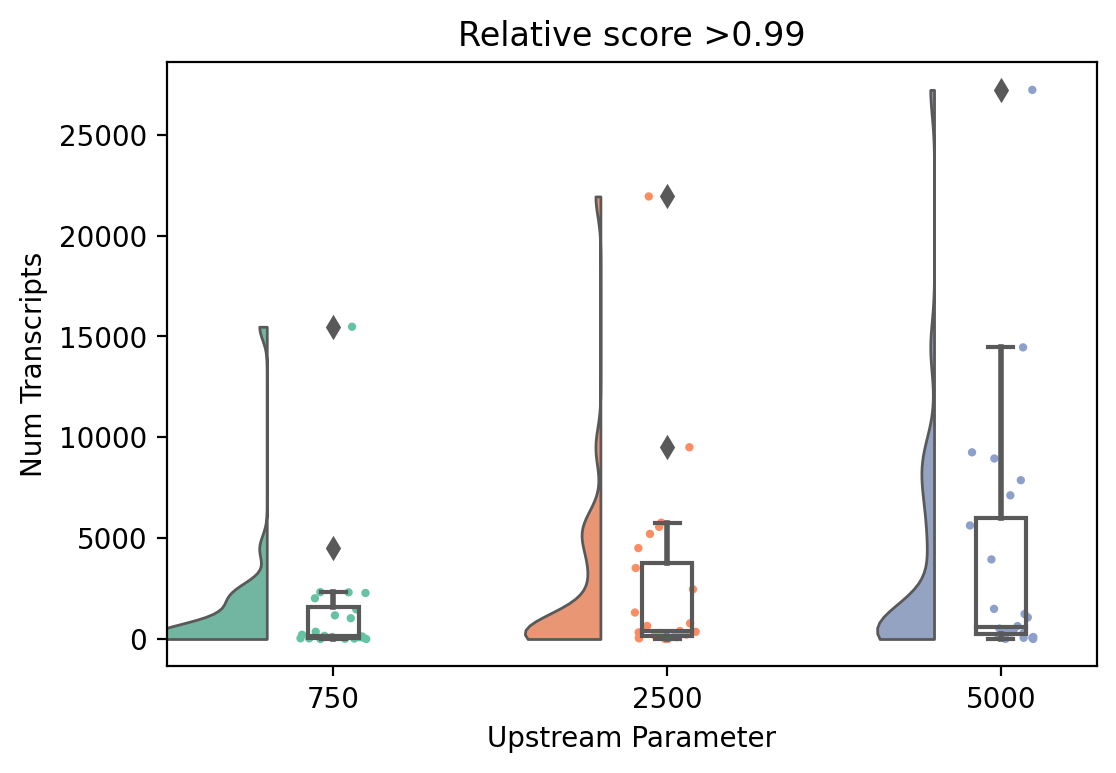

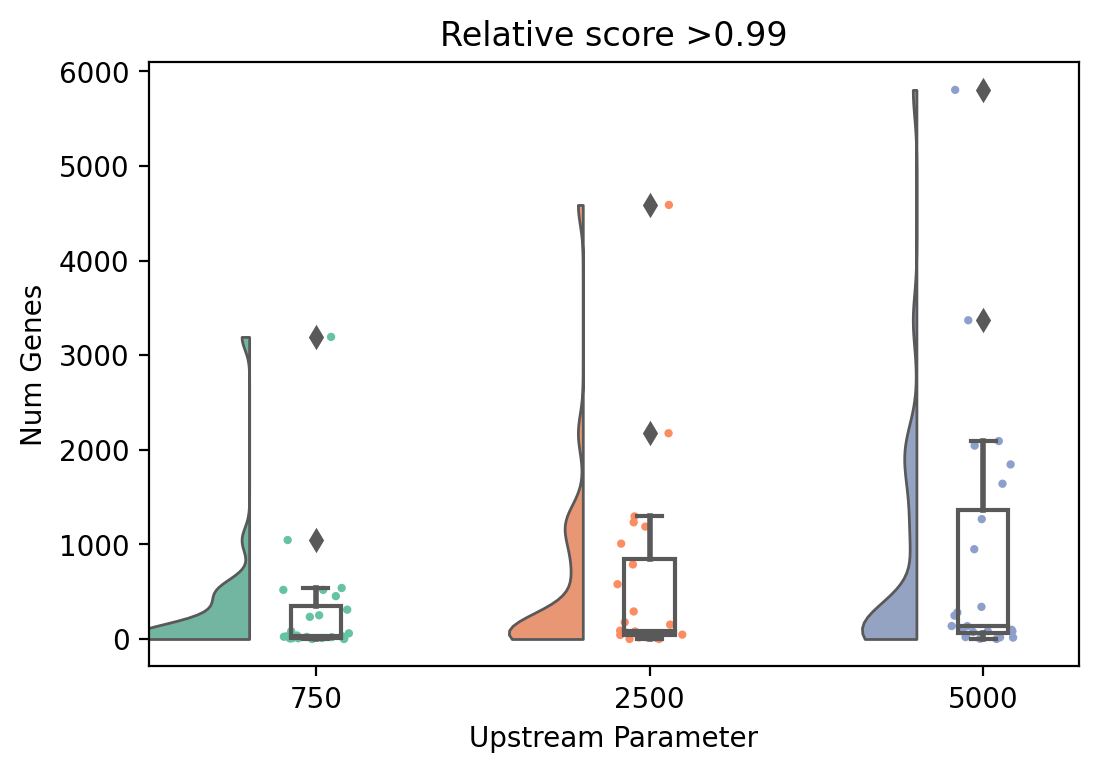

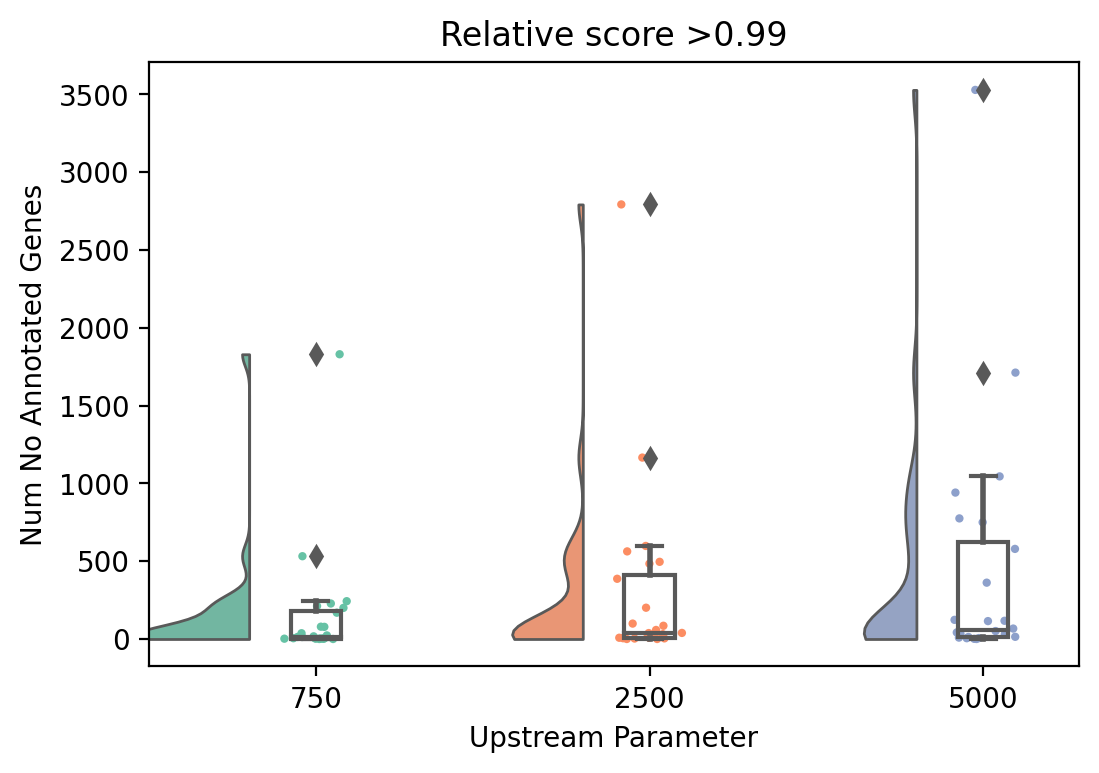

In [12]:
plot_params = ["Num Transcripts", "Num Genes", "Num No Annotated Genes"]

for param in plot_params:
    plt.figure(dpi=200)
    plt.title("Relative score >" + str(threshold/1000))
    ptitprince.RainCloud(x="Upstream Parameter", y=param, data=summary_stat_df)

## P-Values as Function of Relative Scores

In [13]:
p_values_950 = []
p_values_990 = []

for key in tables:

    if "upstream_750" in key: 
    
        tmp = tables[key]

        p_values_950.extend(tmp[tmp[2]>950][3].to_list())

        p_values_990.extend(tmp[tmp[2]>990][3].to_list())



In [14]:
col_1 = []
col_2 = []

for num in p_values_950: 
    col_1.append(num)
    col_2.append(".95")

for num in p_values_990: 
    col_1.append(num)
    col_2.append(".99")


In [15]:
tmp_df =pd.DataFrame(col_1, col_2).reset_index()

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, '750 Upstream')

<AxesSubplot:title={'center':'750 Upstream'}, xlabel='index', ylabel='0'>

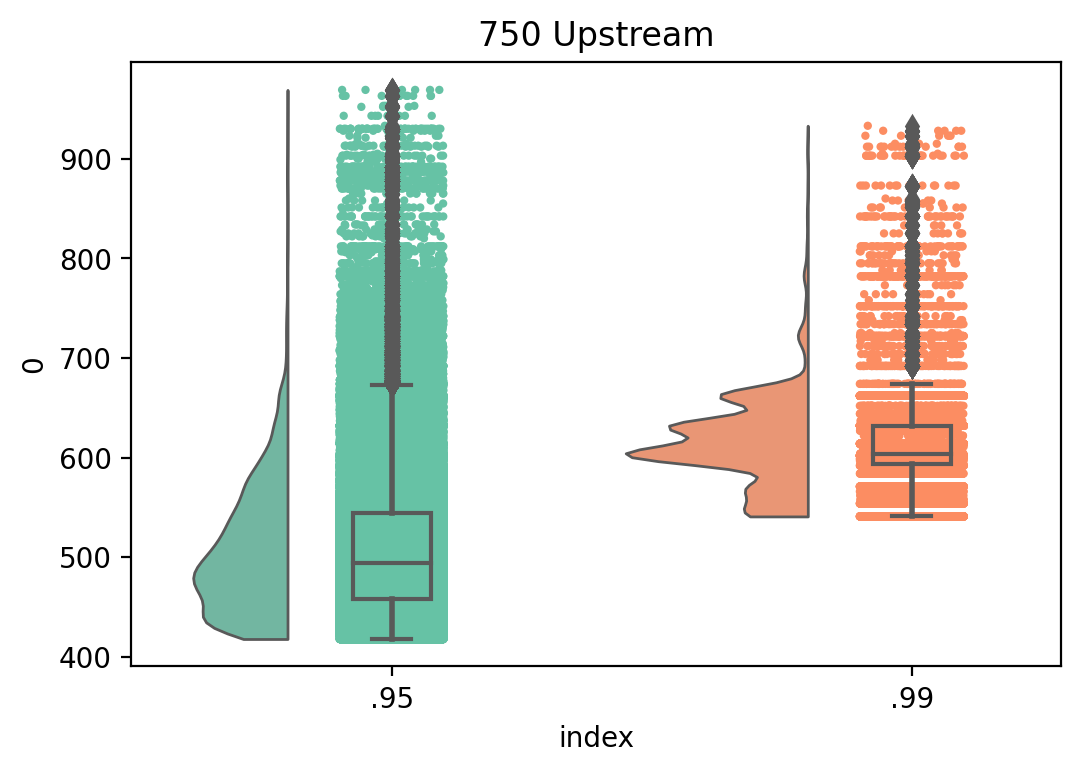

In [16]:
plt.figure(dpi=200)
plt.title("750 Upstream")
ptitprince.RainCloud(x="index", y=0, data=tmp_df)

## Gene Lists

In [17]:
all_genes = []

for key in tables:
    
    threshold = 990
    
    if "upstream_750" in key: 
        
        tmp = tables[key]

        tmp = tmp[tmp[2]>threshold].reset_index()

        tmp = tmp[[1,"Gene stable ID", "Gene name"]].drop_duplicates()

        all_genes.extend(tmp["Gene stable ID"].to_list())

In [18]:
value_counts = pd.Series(all_genes).value_counts()
value_counts.head()

ENSMUSG00000092329    9
ENSMUSG00000051747    7
ENSMUSG00000015243    6
ENSMUSG00000034438    5
ENSMUSG00000035168    5
dtype: int64

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, '990 & 750 Upstream')

<BarContainer object of 20 artists>

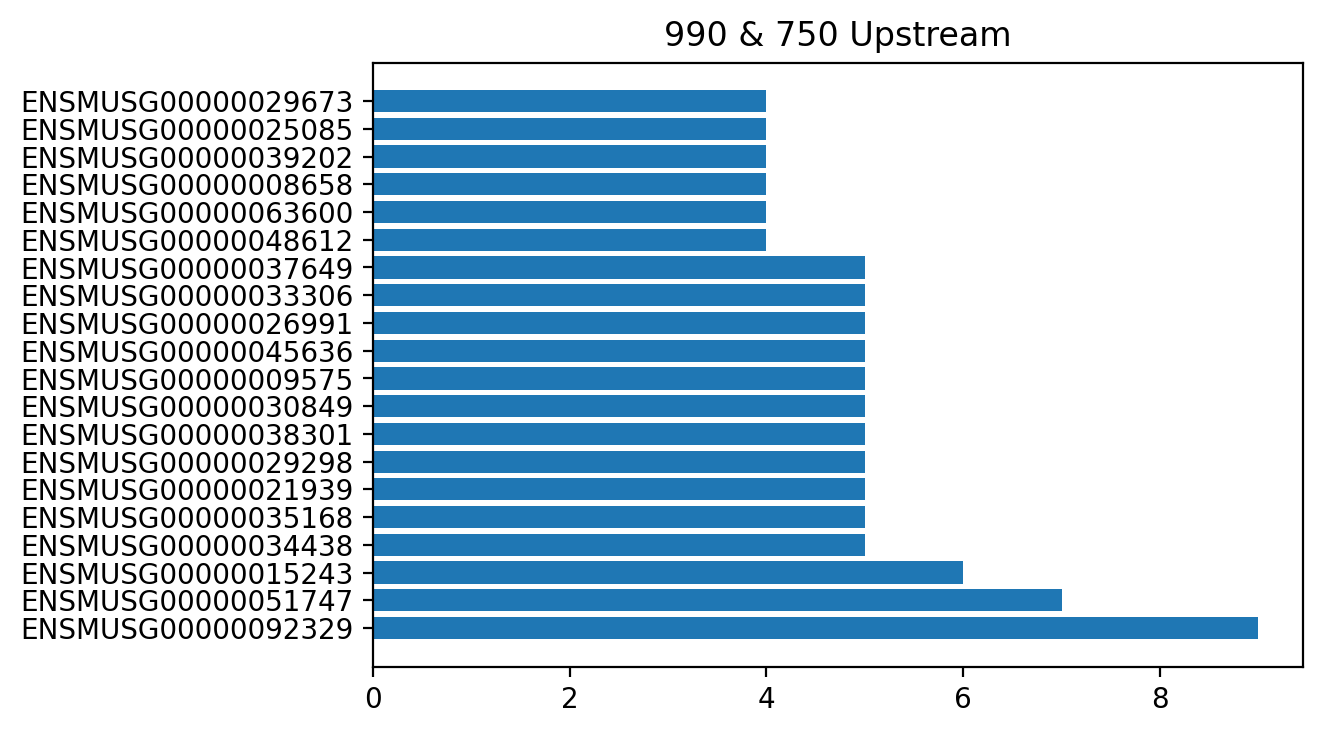

In [19]:
plt.figure(dpi=200)
plt.title("{} & 750 Upstream".format(threshold))

plt.barh(value_counts[0:20].index.tolist(), value_counts[0:20].to_list())

In [20]:
value_counts.index.size

5777

In [21]:
# pd.Series(value_counts.index[0:500]).to_csv("../outputs/top_500_0.99_genes.txt", header=False, index=False)